In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv


--- 
# Imports 
---

In [2]:
###
### SDI2100172 Γεώργιος Σκούρας | Georgios Skouras
###

# Some are unimportant and was used for the commented code  (ingore)
!pip install contractions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import re
import emoji
import html
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import unicodedata
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix
from torch.nn.utils.rnn import pad_sequence
import gensim.downloader as api
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from gensim.models import Phrases
from gensim.models.phrases import Phraser

from wordcloud import WordCloud
from collections import Counter

nltk.download('punkt')  # Download tokenizer models
nltk.download('stopwords')      # Stopwords list
nltk.download('wordnet')        # WordNet lemmatizer data
nltk.download('omw-1.4')        # WordNet lemmatizer language support
# For reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

###
### SDI2100172 Γεώργιος Σκούρας | Georgios Skouras
###

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 7.5 MB/s eta 0:00:00
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


---
# Basic EDA
---

In [3]:
# Load datasets
train_df = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv')
val_df = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv')
test_df = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv')

# Print the shapes of the datasets
print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", val_df.shape)
print("Test dataset shape:", test_df.shape)

# Display a preview of each dataset
print("\nTraining Data Sample:")
print(train_df.head())

print("\nValidation Data Sample:")
print(val_df.head())

print("\nTest Data Sample:")
print(test_df.head())


def basic_eda(df, name):
    print(f"Dataset: {name}")
    print(df.info())  # Overview of dataset
    print(df.describe())  # Statistical summary of numerical data
    print("\nMissing Values:\n", df.isnull().sum())  # Check for missing values
    print("-" * 50)

# Check for missing values and dataset statistics
basic_eda(train_df, "Training Set")
basic_eda(val_df, "Validation Set")
basic_eda(test_df, "Test Set")

Training dataset shape: (148388, 3)
Validation dataset shape: (42396, 3)
Test dataset shape: (21199, 2)

Training Data Sample:
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0

Validation Data Sample:
       ID                                               Text  Label
0  187062  @NatexTheGreat heyheyhey maybe i will  get the...      0
1  168997  @molliesmummy Work? Work was crap. I missed yo...      0
2  194461  Want: Trip to Boston next month. Need: Addit'l...      1
3  165442                        first day starts tomorrow!       1
4   34853  @goodforyoursoul 8 course fish in Little Saigo...      1

Test Data Sample:
       ID    

In [4]:
#
# Taken from project 1
#
def generate_wordcloud(df):
    text_data = ' '.join(df["Text"])  # Join all text into one string
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.title('Word Cloud for Text Data')
    plt.show

def plot_token_frequency(df):
    all_text = ' '.join(df["Text"])  # Join all text into one string
    tokens = word_tokenize(all_text)

    # Remove stopwords and non-alphabetic tokens
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]

    # Calculate token frequencies
    token_frequencies = Counter(tokens)

    # Get the most common 20 tokens
    common_tokens = token_frequencies.most_common(20)

    # Extract words and frequencies
    words, frequencies = zip(*common_tokens)

    # Plot the token frequencies as a bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(words, frequencies, color='skyblue')
    plt.xticks(rotation=45)
    plt.xlabel('Tokens')
    plt.ylabel('Frequency')
    plt.title('Top 20 Tokens Frequency')
    plt.show()
    #print(common_tokens)



def generate_wordcloud_tokens(df, token_col='tokens'):
    
    # Join each list of tokens into a single string, then all into one corpus
    full_corpus = ' '.join(df[token_col].apply(lambda toks: ' '.join(toks)))
    
    # Generate
    wc = WordCloud(width=800, height=400, background_color='white').generate(full_corpus)
    
    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud on Preprocessed Tokens')
    plt.show()


def plot_token_frequency_tokens(df, token_col='tokens'):
    # Flatten the list of token lists into one big list
    all_tokens = [tok for toks in df[token_col] for tok in toks]

    # Remove stopwords and non-alphabetic tokens
    stop_words = set(stopwords.words('english'))
    filtered = [w for w in all_tokens if w.isalpha() and w.lower() not in stop_words]

    # Calculate token frequencies
    token_frequencies = Counter(filtered)

    # Get the most common tokens
    common_tokens = token_frequencies.most_common(20)
    if not common_tokens:
        print("No tokens to display.")
        return

    # Extract words and frequencies
    words, frequencies = zip(*common_tokens)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(words, frequencies, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Tokens')
    plt.ylabel('Frequency')
    plt.title('Top 20 Tokens Frequency on Preprocessed Tokens')
    plt.tight_layout()
    plt.show()

Training dataset shape: (148388, 3)

Columns in the dataset: ['ID', 'Text', 'Label']

Data types:
ID        int64
Text     object
Label     int64
dtype: object

Missing values per column:
ID       0
Text     0
Label    0
dtype: int64

Label distribution:
Label
1    74196
0    74192
Name: count, dtype: int64

Tweet length statistics:
count    148388.000000
mean         13.289161
std           6.937913
min           1.000000
25%           8.000000
50%          12.000000
75%          19.000000
max         111.000000
Name: tweet_length, dtype: float64


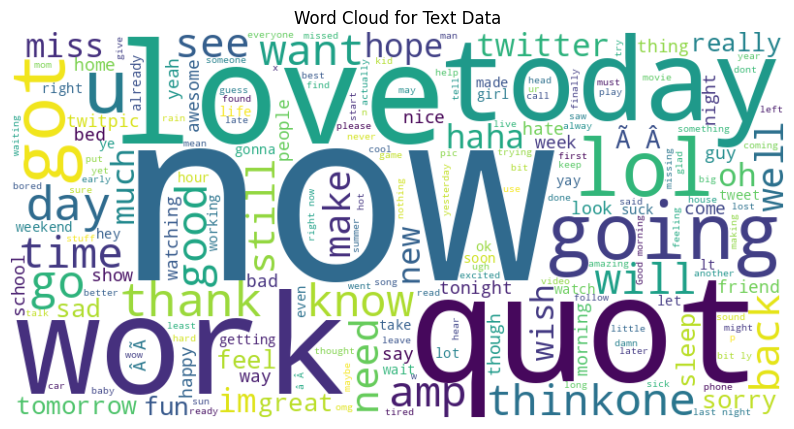

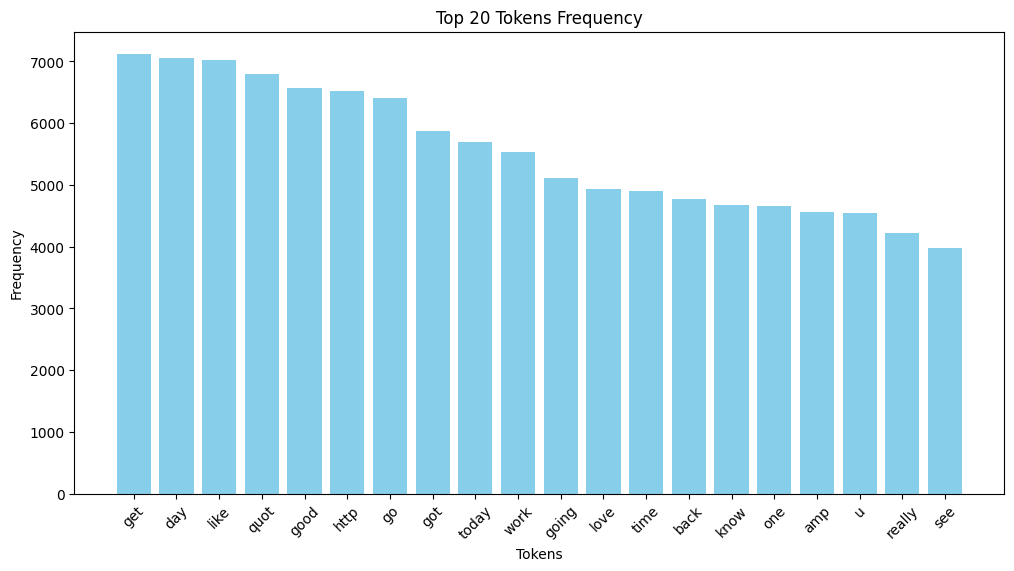

In [5]:
# Display basic information about the dataset
print("Training dataset shape:", train_df.shape)
print("\nColumns in the dataset:", train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)
print("\nMissing values per column:")
print(train_df.isnull().sum())

# Analyze label distribution
label_counts = train_df['Label'].value_counts()
print("\nLabel distribution:")
print(label_counts)


generate_wordcloud(train_df);

# Analyze tweet lengths (number of words per tweet)
train_df['tweet_length'] = train_df['Text'].apply(lambda x: len(x.split()))
print("\nTweet length statistics:")
print(train_df['tweet_length'].describe())

# Plot the tweet length distribution
plot_token_frequency(train_df);

---
# Pre-Process
---


Sample tokens from training data:
                                                Text  \
0      @whoisralphie dude  I'm so bummed ur leaving!   
1  oh my god, a severed foot was foun in a wheely...   
2  I end up &quot;dog dialing&quot; sumtimes. Wha...   
3                         @_rachelx meeeee toooooo!    
4  I was hoping I could stay home and work today,...   
5  says plurk karma finally reached the 50s. stil...   
6  Good to hear it @Arth This is a bit more, but ...   
7  @davorg in that case im gonna start tweeting a...   
8          @belunyc its alright love, how are you?     
9  @brightondoll haha that has to be the best ana...   

                                              tokens  
0  [USER, dude, i, am, so, bummed, you, are, leav...  
1  [oh, my, god, a, severed, foot, was, foun, in,...  
2  [i, end, up, QUOTE, dog, dialing, QUOTE, sumti...  
3                        [USER, me, to, EXCLAMATION]  
4  [i, was, hoping, i, could, stay, home, and, wo...  
5  [says, plurk, ka

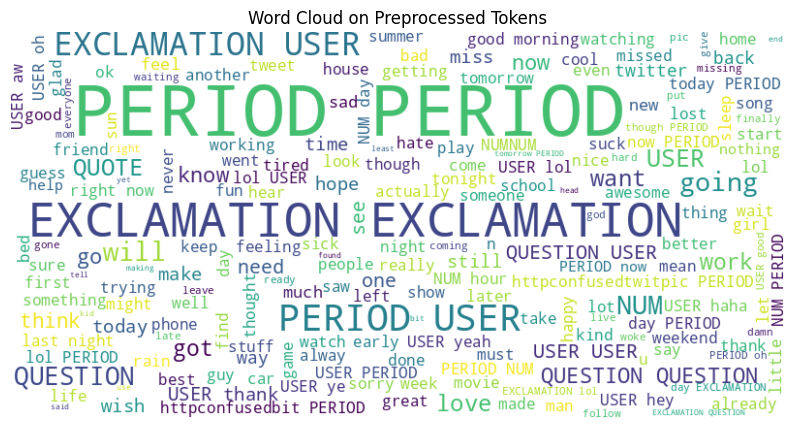

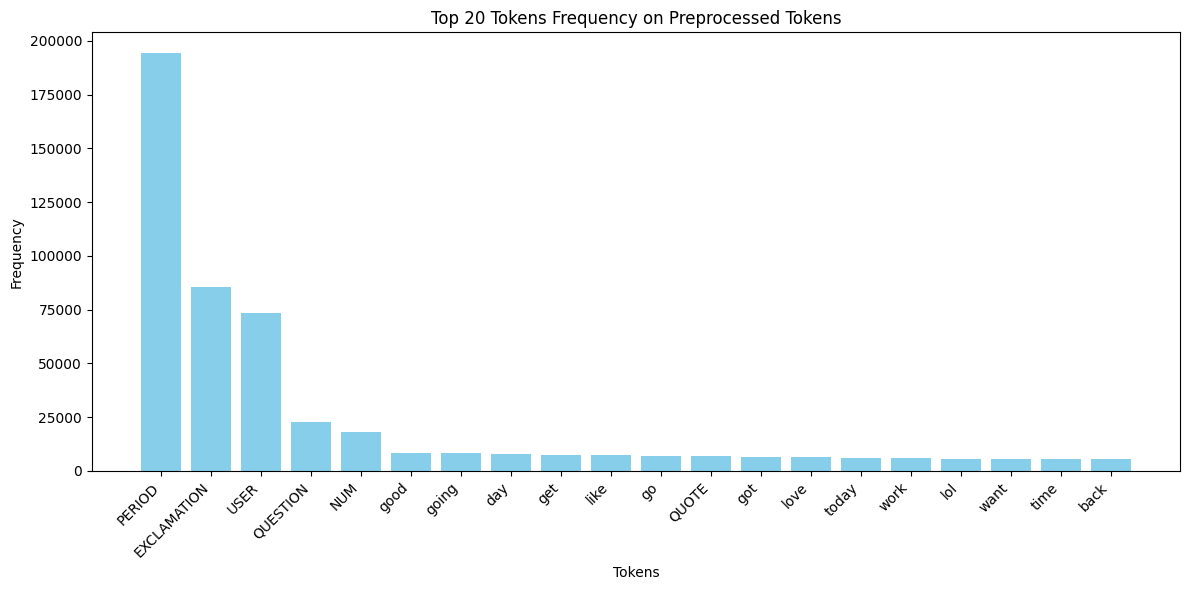

In [6]:
#
# Taken from project 1 with some adjustments 
#
abbreviations = {
    "u": "you", "ur": "your", "r": "are", "pls": "please", "thx": "thanks",
    "k": "okay","y": "why"
}

emoticon_dict = {
    ":)": "happy",    
    ":D": "laughing",    
    ";)": "wink",    
    ":(": "sad",    
    ":/": "confused",    
    ":|": "neutral",    
    ":'(": "crying",    
    ":o": "surprised",    
    ":O": "shocked",    
}

#Replace common emoticons with their descriptive meanings.
def preprocess_emojis(text):
    
    for emoticon, meaning in emoticon_dict.items():
        text = re.sub(re.escape(emoticon), meaning, text)
    return text


# Function to expand contractions compactly
def expand_contractions(text):
    return re.sub(r'\b(' + '|'.join(contractions.keys()) + r')\b', lambda x: contractions[x.group(0).lower()], text)

# Function to expand abbreviations compactly
def expand_abbreviations(text):
    return re.sub(r'\b(' + '|'.join(abbreviations.keys()) + r')\b', lambda x: abbreviations[x.group(0)], text)


#conver some punctation to show meaning 
def convert_punctuation(text):
    text = text.replace("!", " <EXCLAMATION> ")
    text = text.replace("?", " <QUESTION> ")
    text = text.replace(".", " <PERIOD> ")  
    text = text.replace('"', " <QUOTE> ")
    
    
    return text



def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    text = html.unescape(text)
    text = contractions.fix(text)
    # funtions for replacing 
    # text = expand_contractions(text)
    text = expand_abbreviations(text)
    text = preprocess_emojis(text)
    
    # Replace emails with "Email"
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '<EMAIL>', text)


    text = convert_punctuation(text)
    # Replace URLs with "Url_link"
    text = re.sub(r'https?://\S+|www\.\S+', '<URL_LINK>', text)

    text = re.sub(r'@\w+', '<USER>', text)  # Replace all @mentions with "USER"

    # Reduce sequences of repeated characters to a maximum of 2 (or 1)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Replace standalone numbers with "Num"
    text = re.sub(r'\d+', '<NUM>', text)
    
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
   
    tokens = word_tokenize(text)
    return tokens



train_df['tokens'] = train_df['Text'].apply(preprocess_text)
# Clean and tokenize tweets in the validation dataset
val_df['tokens'] = val_df['Text'].apply(preprocess_text)
# Clean and tokenize tweets in the test dataset
test_df['tokens'] = test_df['Text'].apply(preprocess_text)

# Display sample tokens from training data
print("Sample tokens from training data:")
print(train_df[['Text', 'tokens']].head(10))

generate_wordcloud_tokens(train_df);

plot_token_frequency_tokens(train_df);

In [7]:
#
# Taken from project 1 with adjustments to fit with current model 
#
def plot_roc_curve(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features).view(-1)
            all_probs.extend(outputs.tolist())
            all_labels.extend(labels.tolist())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features).view(-1)
            preds = (outputs >= 0.5).int()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1, linecolor='black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


def plot_learning_curve(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



---
# WORD2VEC
---

In [8]:
#--------------------------------------------------------------       was used for better results as it expands the dataset
#combined_df = pd.concat([train_df, val_df], ignore_index=True)
#combined_sentences = combined_df['tokens'].tolist()
#combined_df['embeddings'] = combined_df['tokens'].apply(lambda x: tokens_to_vectors(x, w2v_model, embedding_dim))
#combined_dataset = TweetDataset(combined_df)
#combined_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#--------------------------------------------------------------



# Prepare the training sentences (list of tokenized tweets)
train_sentences = train_df['tokens'].tolist() 

# Build a bigram detection model from your training sentences.
bigram_model = Phrases(train_sentences, min_count=3, threshold=5)
# Wrap the Phrases model in a more efficient Phraser for fast transformation.
bigram_phraser = Phraser(bigram_model)

# Apply the trained bigram phraser to each sentence in the training set.
bigram_sentences = [bigram_phraser[sentence] for sentence in train_sentences]

vsize = 400; 
w2v_model = Word2Vec(
    sentences=bigram_sentences,
    vector_size=vsize, window=7, min_count=2,
    workers=4, seed=seed, sg=1, negative=15, epochs=10
)
print("Word2Vec model trained on the training data!")

# Define the embedding dimension based on the trained model
embedding_dim = w2v_model.vector_size

# Function to convert tokens into a sequence of vectors using your trained model
def tokens_to_vectors(tokens, model, dim):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if not vectors:
        # Return a single zero vector if no valid tokens were found
        return np.zeros((1, dim))
    return np.array(vectors)

# Map tokens to vectors for each dataset
print("Mapping tokens to vectors for training data...")
train_df['embeddings'] = train_df['tokens'].apply(lambda x: tokens_to_vectors(x, w2v_model, embedding_dim))
print("Mapping tokens to vectors for validation data...")
val_df['embeddings'] = val_df['tokens'].apply(lambda x: tokens_to_vectors(x, w2v_model, embedding_dim))
print("Mapping tokens to vectors for test data...")
test_df['embeddings'] = test_df['tokens'].apply(lambda x: tokens_to_vectors(x, w2v_model, embedding_dim))

# Display an example: show the tokens and the shape of its corresponding embedding matrix
print("\nExample tweet tokens:")
print(train_df['tokens'].iloc[0])
print("Shape of the corresponding embedding matrix:", train_df['embeddings'].iloc[0].shape)


#----------- checking the partions -----------#
# print("Training set size:", len(train_df))
# print("Validation set size:", len(val_df))
# print("Test set size:", len(test_df))

# # Check the total dataset size
# total_size = len(train_df) + len(val_df) + len(test_df)
# print("Total dataset size:", total_size)

# # Check the percentage of each partition
# print("Train ratio:", len(train_df) / total_size)
# print("Validation ratio:", len(val_df) / total_size)
# print("Test ratio:", len(test_df) / total_size)
#--------------------------------------------#

Word2Vec model trained on the training data!
Mapping tokens to vectors for training data...
Mapping tokens to vectors for validation data...
Mapping tokens to vectors for test data...

Example tweet tokens:
['USER', 'dude', 'i', 'am', 'so', 'bummed', 'you', 'are', 'leaving', 'EXCLAMATION']
Shape of the corresponding embedding matrix: (10, 400)


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 | train Loss: 0.5172 | val loss: 0.4843 |Val Acc: 0.7661 | Val Prec: 0.8110 | Val Recall: 0.6940 | Val F1: 0.7480
Epoch 2/20 | train Loss: 0.4873 | val loss: 0.4713 |Val Acc: 0.7730 | Val Prec: 0.7818 | Val Recall: 0.7574 | Val F1: 0.7694
Epoch 3/20 | train Loss: 0.4804 | val loss: 0.4692 |Val Acc: 0.7750 | Val Prec: 0.7808 | Val Recall: 0.7647 | Val F1: 0.7726
Epoch 4/20 | train Loss: 0.4767 | val loss: 0.4661 |Val Acc: 0.7766 | Val Prec: 0.7972 | Val Recall: 0.7419 | Val F1: 0.7686
Epoch 5/20 | train Loss: 0.4706 | val loss: 0.4619 |Val Acc: 0.7794 | Val Prec: 0.7963 | Val Recall: 0.7509 | Val F1: 0.7730
Epoch 6/20 | train Loss: 0.4673 | val loss: 0.4620 |Val Acc: 0.7782 | Val Prec: 0.7716 | Val Recall: 0.7904 | Val F1: 0.7809
Epoch 7/20 | train Loss: 0.4645 | val loss: 0.4584 |Val Acc: 0.7811 | Val Prec: 0.7985 | Val Recall: 0.7519 | Val F1: 0.7745
Epoch 8/20 | train Loss: 0.4605 | val loss: 0.4564 |Val Acc: 0.7819 | Val Prec: 0.7893 | Val Recall: 0.7690 | Val F1: 0.7790


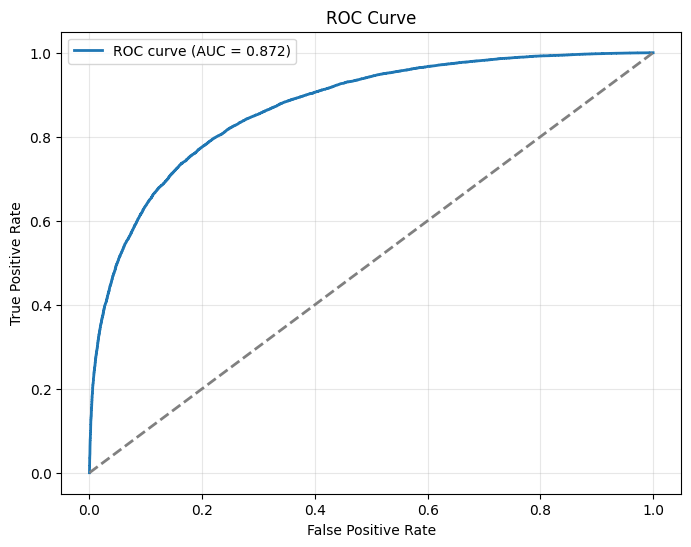

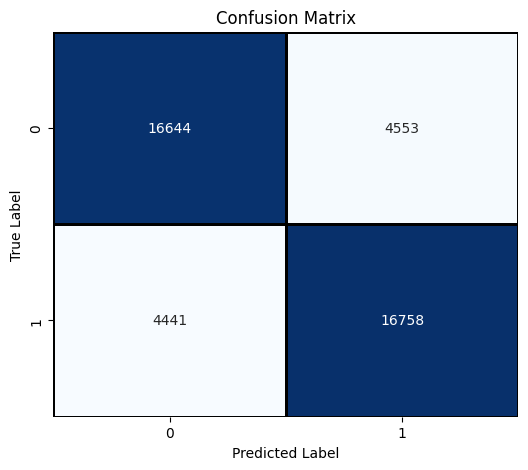

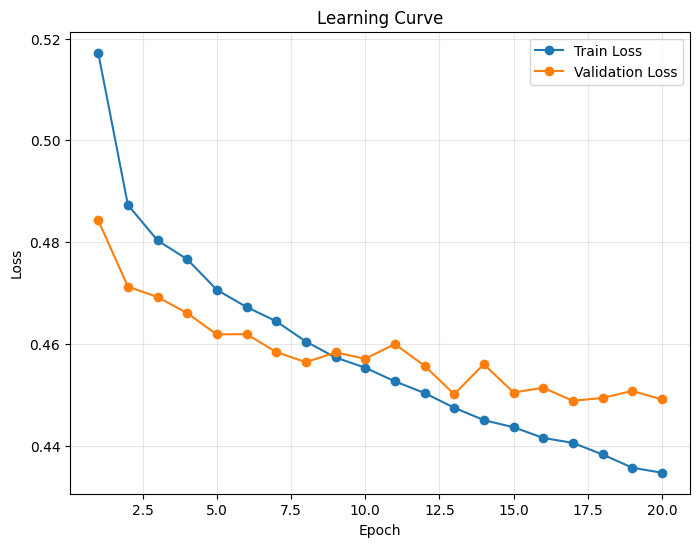

In [9]:
# Dataset for train and validation (with labels)
class TweetDataset(Dataset):
    def __init__(self, df):
        self.df = df
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        embeddings = self.df.iloc[idx]['embeddings']
        avg_embedding = torch.tensor(embeddings.mean(axis=0), dtype=torch.float32)
        label = torch.tensor(self.df.iloc[idx]['Label'], dtype=torch.float32)
        return avg_embedding, label

# Dataset for test (no labels)
class TweetTestDataset(Dataset):
    def __init__(self, df):
        self.df = df
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        embeddings = self.df.iloc[idx]['embeddings']
        avg_embedding = torch.tensor(embeddings.mean(axis=0), dtype=torch.float32)
        return avg_embedding

# Create datasets
train_dataset = TweetDataset(train_df)
val_dataset = TweetDataset(val_df)

test_dataset = TweetTestDataset(test_df)

# Create DataLoaders
batch_size = 256 # 64, 128, 256 , 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Define a simple feedforward neural network
class SentimentClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SentimentClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)  # First dropout after fc1
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.dropout2 = nn.Dropout(0.4)  # Second dropout after fc2
        self.fc3 = nn.Linear(64, 1)  # Output layer
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Initialize model, loss, optimizer
input_dim = vsize
hidden_dim = 256  #128 , 256 , 512
model = SentimentClassifier(input_dim, hidden_dim)
# Set up the optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, eps=1e-5, betas=(0.9, 0.999), weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
criterion = nn.BCELoss()

train_losses = []
val_losses   = []


# Training loop--
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for features, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(features).view(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_loss)
    # Now compute training metrics using the same combined data
    model.eval()  # Switch to evaluation mode
    val_true = []
    val_preds = []
    total_val_loss = 0
    with torch.no_grad():
        for features, labels in val_loader:
            outputs = model(features).view(-1)
            preds = (outputs >= 0.5).float().tolist()  # Convert probabilities to binary predictions (0 or 1)
            loss = criterion(outputs,labels)
            total_val_loss += loss.item()
            
            val_preds.extend(preds)
            val_true.extend(labels.tolist())


    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    
    # Compute validation metrics using scikit-learn
    val_accuracy = accuracy_score(val_true, val_preds)
    val_precision = precision_score(val_true, val_preds)
    val_recall = recall_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds)

    print(f"Epoch {epoch+1}/{num_epochs} | train Loss: {avg_loss:.4f} | val loss: {avg_val_loss:.4f} |"
          f"Val Acc: {val_accuracy:.4f} | Val Prec: {val_precision:.4f} | "
          f"Val Recall: {val_recall:.4f} | Val F1: {val_f1:.4f}")

    # Step the learning rate scheduler based on validation loss
    scheduler.step(avg_loss)  # Pass validation loss to scheduler

# Calling for the functions 
plot_roc_curve(model, val_loader)
plot_confusion_matrix(model, val_loader)
plot_learning_curve(train_losses, val_losses)

---
# Sumbmission
---

In [10]:
model.eval()
all_test_preds = []

with torch.no_grad():
    for batch in test_loader:
        # If DataLoader wraps your single‐tensor dataset in a tuple, handle both cases
        if isinstance(batch, (list, tuple)):
            features = batch[0]
        else:
            features = batch

        outputs = model(features).view(-1)            
        preds   = (outputs >= 0.5).int().tolist()     
        all_test_preds.extend(preds)

# Build and save submission
submission_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": all_test_preds
})
submission_df.to_csv("submission.csv", index=False)
print("✅ Submission file saved as submission.csv")

✅ Submission file saved as submission.csv


---
---
# NOT USING (cnn method not allowed)
---

In [11]:
#Epoch 20/20 | Loss: 0.4369 | Val Acc: 0.7867 | Val Prec: 0.7762 | Val Recall: 0.8057 | Val F1: 0.7907
#Epoch 20/20 | Loss: 0.4962 | Val Acc: 0.7529 | Val Prec: 0.7624 | Val Recall: 0.7348 | Val F1: 0.7483

# vsize = 400; seed = 42
# w2v_model = Word2Vec(
#     sentences=bigram_sentences,
#     vector_size=vsize, window=7, min_count=2,
#     workers=4, seed=seed, sg=1, negative=15, epochs=10
# )

# optimizer = optim.AdamW(model.parameters(), lr=0.001, eps=1e-5, betas=(0.9, 0.999), weight_decay=1e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

#--------------------------
# combined_df = pd.concat([train_df, val_df], ignore_index=True)
# combined_sentences = combined_df['tokens'].tolist()

# bigram_model = Phrases(combined_sentences, min_count=3, threshold=5)
# bigram_phraser = Phraser(bigram_model)
# bigram_sentences = [bigram_phraser[sentence] for sentence in combined_sentences]

# vsize = 400
# seed = 42
# w2v_model = Word2Vec(
#     sentences=bigram_sentences, 
#     vector_size=vsize,
#     window=7, 
#     min_count=2,
#     workers=4,
#     seed=seed,
#     sg=1,
#     negative=15,
#     epochs=10
# )
# print("Word2Vec model trained on the training data!")

# embedding_dim = w2v_model.vector_size

# # For CNN, we don't average the embeddings. Instead, we need the raw sequence.
# # First, define a helper function to convert a list of tokens to a sequence of vectors.
# def tokens_to_sequence(tokens, model, dim):
#     vectors = [model.wv[token] for token in tokens if token in model.wv]
#     if not vectors:
#         # Return an empty 2D array with 0 rows and 'dim' columns
#         return np.zeros((0, dim))
#     return np.array(vectors)  # shape: (num_tokens, dim)

# # Map tokens to sequences of vectors for each dataset.
# # We'll produce a new column 'sequence' in our DataFrames.
# val_df['sequence'] = val_df['tokens'].apply(lambda x: tokens_to_sequence(x, w2v_model, embedding_dim))
# combined_df['sequence'] = combined_df['tokens'].apply(lambda x: tokens_to_sequence(x, w2v_model, embedding_dim))
# test_df['sequence'] = test_df['tokens'].apply(lambda x: tokens_to_sequence(x, w2v_model, embedding_dim))

# # Display an example: tweet tokens and shape of its corresponding sequence.
# print("\nExample tweet tokens:")
# print(combined_df['tokens'].iloc[0])
# print("Shape of the corresponding embedding sequence:", combined_df['sequence'].iloc[0].shape)

# # Next, for CNN, we need to pad sequences to a fixed length.
# # Let's choose a maximum sequence length (for example, 50 tokens). You can also compute the max length from your corpus.
# #max_seq_len = 30

# # def pad_sequence(seq, max_len, dim):
# #     # seq: expected shape (num_tokens, dim)
# #     if seq.shape[0] >= max_len:
# #         return seq[:max_len]
# #     else:
# #         pad = np.zeros((max_len - seq.shape[0], dim))
# #         return np.concatenate((seq, pad), axis=0)

# # # Apply padding to the sequence column.
# # val_df['padded'] = val_df['sequence'].apply(lambda x: pad_sequence(x, max_seq_len, embedding_dim))
# # combined_df['padded'] = combined_df['sequence'].apply(lambda x: pad_sequence(x, max_seq_len, embedding_dim))
# # test_df['padded'] = test_df['sequence'].apply(lambda x: pad_sequence(x, max_seq_len, embedding_dim))

# # Check an example padded shape:
# #print("\nExample padded sequence shape:", combined_df['padded'].iloc[0].shape)  # Should be (max_seq_len, embedding_dim)

In [12]:
# # Create new Dataset classes for CNN that return padded sequences.
# class TweetCNNDataset(Dataset):
#     def __init__(self, df):
#         self.df = df
    
#     def __len__(self):
#         return len(self.df)
    
#     def __getitem__(self, idx):
#         #sequence = self.df.iloc[idx]['padded']  # shape: (max_seq_len, embedding_dim)
#         sequence = self.df.iloc[idx]['sequence']
#         sequence_tensor = torch.tensor(sequence, dtype=torch.float32)
#         label = torch.tensor(self.df.iloc[idx]['Label'], dtype=torch.float32)
#         return sequence_tensor, label

# class TweetCNNTestDataset(Dataset):
#     def __init__(self, df):
#         self.df = df
    
#     def __len__(self):
#         return len(self.df)
    
#     def __getitem__(self, idx):
#         #sequence = self.df.iloc[idx]['padded']
#         sequence = self.df.iloc[idx]['sequence']
#         sequence_tensor = torch.tensor(sequence, dtype=torch.float32)
#         # Return a dummy label (e.g., 0) so that it fits the expected (features, label) tuple
#         return sequence_tensor, torch.tensor(0.0)



# def custom_collate_fn(batch):
#     sequences, labels = zip(*batch)
#     padded_sequences = pad_sequence(sequences)  # shape: (max_len, batch, embed_dim)
#     padded_sequences = padded_sequences.transpose(0, 1)  # shape: (batch, max_len, embed_dim)
#     labels = torch.stack(labels)
#     return padded_sequences, labels


# # Create datasets and dataloaders for CNN.
# val_cnn_dataset = TweetCNNDataset(val_df)
# combined_cnn_dataset = TweetCNNDataset(combined_df)
# test_cnn_dataset = TweetCNNTestDataset(test_df)


# batch_size = 256
# # val_cnn_loader = DataLoader(val_cnn_dataset, batch_size=batch_size, shuffle=False)
# # combined_cnn_loader = DataLoader(combined_cnn_dataset, batch_size=batch_size, shuffle=True)
# # test_cnn_loader = DataLoader(test_cnn_dataset, batch_size=batch_size, shuffle=False)
# val_cnn_loader = DataLoader(val_cnn_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
# combined_cnn_loader = DataLoader(combined_cnn_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
# test_cnn_loader = DataLoader(test_cnn_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

# # Define a CNN-based text classifier.0
# class CNNTextClassifier(nn.Module):
#     def __init__(self, embedding_dim, num_filters, filter_sizes, hidden_dim, dropout_rate):
#         super(CNNTextClassifier, self).__init__()
#         # Convolution layers: one for each filter size.
#         self.convs = nn.ModuleList([
#             nn.Conv2d(1, num_filters, (fs, embedding_dim))
#             for fs in filter_sizes
#         ])
#         self.dropout = nn.Dropout(dropout_rate)
#         self.fc1 = nn.Linear(num_filters * len(filter_sizes), hidden_dim)
#         self.fc2 = nn.Linear(hidden_dim, 1)
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         # x shape: (batch, max_seq_len, embedding_dim)
#         x = x.unsqueeze(1)  # shape: (batch, 1, max_seq_len, embedding_dim)
#         conved = [torch.relu(conv(x)).squeeze(3) for conv in self.convs]  # Each: (batch, num_filters, L_out)
#         pooled = [torch.max(feature_map, dim=2)[0] for feature_map in conved]  # Each: (batch, num_filters)
#         cat = torch.cat(pooled, dim=1)  # shape: (batch, num_filters * len(filter_sizes))
#         x = self.dropout(cat)
#         x = torch.relu(self.fc1(x))
#         x = self.dropout(x)
#         x = self.fc2(x)
#         x = self.sigmoid(x)
#         return x

# # Initialize the CNN model.
# # Choose filter sizes such as [2, 3, 4] and number of filters per size.
# num_filters = 100
# filter_sizes = [2,3,4]
# hidden_dim = 256
# cnn_model = CNNTextClassifier(embedding_dim, num_filters, filter_sizes, hidden_dim, dropout_rate=0.5)

# # Set up optimizer, loss, scheduler for CNN model.
# optimizer = optim.AdamW(cnn_model.parameters(), lr=0.001, eps=1e-5, betas=(0.9, 0.999), weight_decay=1e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
# criterion = nn.BCELoss()

# # Training loop for CNN model.
# num_epochs = 6
# for epoch in range(num_epochs):
#     cnn_model.train()
#     total_loss = 0
#     for sequences, labels in combined_cnn_loader:
#         optimizer.zero_grad()
#         outputs = cnn_model(sequences).view(-1)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     avg_loss = total_loss / len(combined_cnn_loader)
    
#     cnn_model.eval()
#     val_true = []
#     val_preds = []
#     with torch.no_grad():
#         for sequences, labels in val_cnn_loader:
#             outputs = cnn_model(sequences).view(-1)
#             preds = (outputs >= 0.5).float().tolist()
#             val_preds.extend(preds)
#             val_true.extend(labels.tolist())
    
#     val_accuracy = accuracy_score(val_true, val_preds)
#     val_precision = precision_score(val_true, val_preds)
#     val_recall = recall_score(val_true, val_preds)
#     val_f1 = f1_score(val_true, val_preds)
    
#     print(f"CNN Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | "
#           f"Val Acc: {val_accuracy:.4f} | Val Prec: {val_precision:.4f} | "
#           f"Val Recall: {val_recall:.4f} | Val F1: {val_f1:.4f}")
    
#     scheduler.step(avg_loss)